<a href="https://colab.research.google.com/github/Adityapatil1309/Adityapatil1309/blob/main/Netflix_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files
uploaded = files.upload()


Saving netflix_titles.csv to netflix_titles.csv


In [8]:
import os
print(os.listdir())

['.config', 'netflix_titles.csv', 'sample_data']


In [9]:
import pandas as pd

df = pd.read_csv('netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [12]:
df.shape


(8807, 12)

In [13]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [15]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [16]:
df.duplicated().sum()

np.int64(0)

Dataset Summary

1. The dataset contains Netflix Movies and TV Shows.
2. It includes information such as title, director, cast, country, rating and release year.
3. The dataset contains 8807 records and 12 columns.
4. The dataset includes both categorical and text-based features.
5. It can be used to analyze content trends, ratings and production patterns on Netflix.

In [18]:
# Fill missing values

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Fill with most common value
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Remove rows with missing date_added and duration
df.dropna(subset=['date_added', 'duration'], inplace=True)

# Check again
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


Data Cleaning Performed

1. Missing values in director, cast, and country were replaced with "Unknown".
2. Missing values in rating were filled using the most frequent rating.
3. Rows with missing date_added and duration were removed.
4. No duplicate records were found in the dataset.
5. The dataset was cleaned to improve analysis accuracy.

In [19]:
df['type'].value_counts()

,count
type,
Movie,6128
TV Show,2666


Question 1: How many Movies and TV Shows are available on Netflix?

The dataset contains both Movies and TV Shows. Movies are significantly higher in number compared to TV Shows.

In [20]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3209
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


Question 2: What are the most common content ratings on Netflix?

TV-MA and TV-14 are among the most common content ratings, indicating that Netflix contains a large amount of mature and teen-oriented content.

In [21]:
df['release_year'].value_counts().head(10)

,count
release_year,
2018,1146
2017,1031
2019,1030
2020,953
2016,901
2021,592
2015,557
2014,352
2013,287


Question 3: Which years had the highest number of Netflix releases?

Netflix content releases increased significantly in recent years, with some years showing a much higher number of releases than others.

In [22]:
df['country'].value_counts().head(10)

,count
country,
United States,2809
India,972
Unknown,830
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


Question 4: Which countries produce the most Netflix content?

The United States contributes the highest amount of content, followed by several other countries.

In [23]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,219
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


Question 5: What are the most popular genres on Netflix?

Some genres appear more frequently than others, showing Netflix's focus on specific content categories.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns





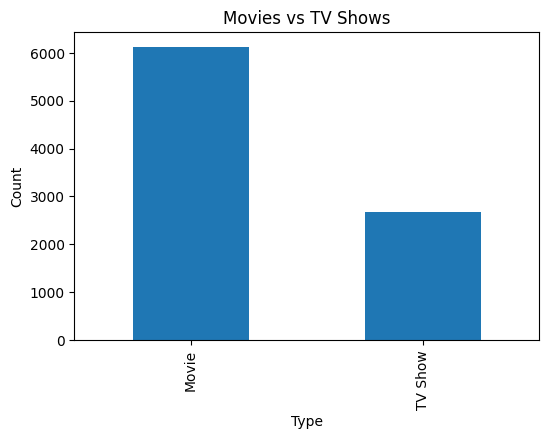

In [29]:
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar')
plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

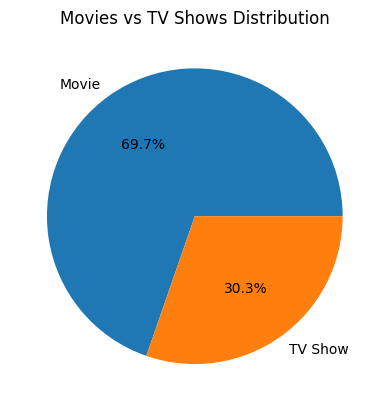

In [30]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Movies vs TV Shows Distribution')
plt.ylabel('')
plt.show()

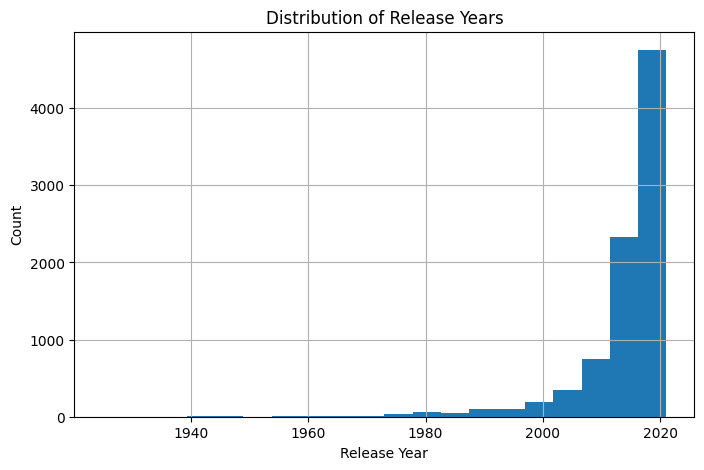

In [31]:
plt.figure(figsize=(8,5))
df['release_year'].hist(bins=20)
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

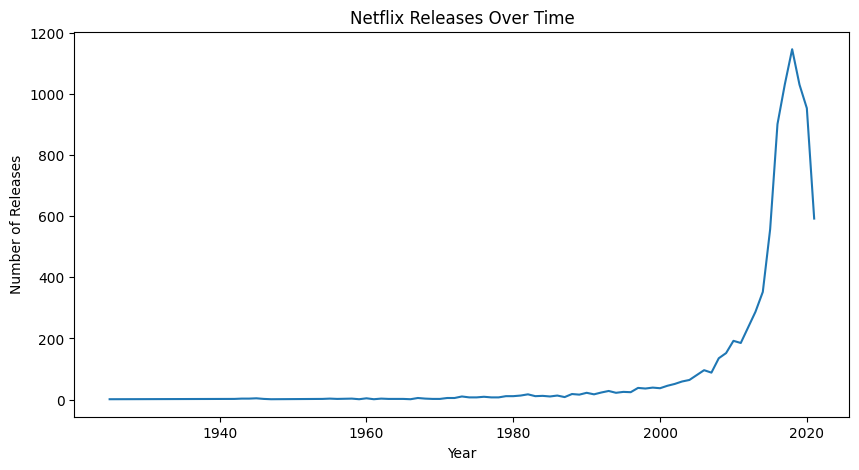

In [32]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
year_counts.plot()
plt.title('Netflix Releases Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.show()

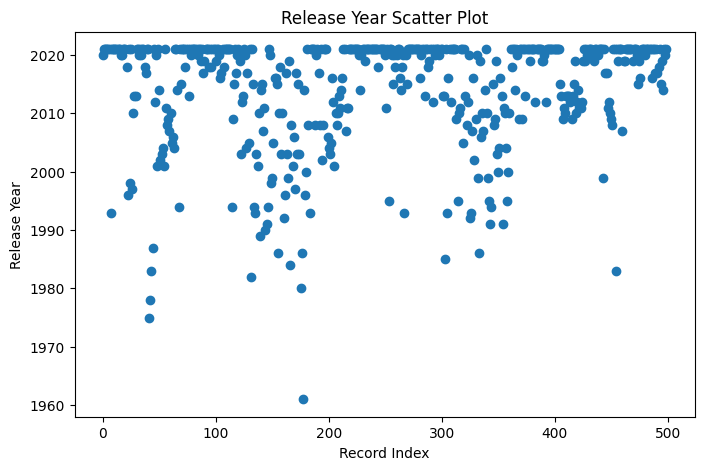

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(df.index[:500], df['release_year'][:500])
plt.title('Release Year Scatter Plot')
plt.xlabel('Record Index')
plt.ylabel('Release Year')
plt.show()

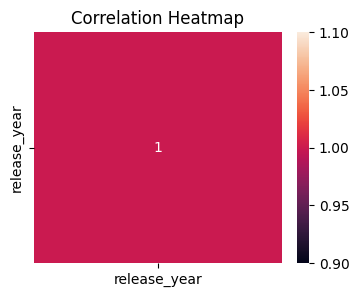

In [34]:
plt.figure(figsize=(4,3))
sns.heatmap(df[['release_year']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [35]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,219
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


Question 5: What are the most popular genres on Netflix?

The most common genre category is "Dramas, International Movies" with 362 titles, followed by "Documentaries" and "Stand-Up Comedy". This shows that Netflix offers a large amount of international drama content and documentary-based entertainment.